---
title: Joint probability
---

Phase-type distributions can be extended to model joint probabilities of multiple random variables. This is particularly important in applications like population genetics, where we might be interested in the joint distribution of coalescence times for multiple lineages, or in reliability theory, where we might want the joint distribution of failure times for multiple components. This section shows how to compute exact joint probabilities.

<!-- 
The key idea is that we can embed multiple independent or dependent processes into a single state space, where the state vector encodes the progress of all processes simultaneously. Transitions in this joint state space correspond to events in the individual processes. 

By carefully constructing the edge weights and using reward transformations, we can extract marginal distributions, conditional distributions, and joint distribution functions.

In our rabbit model, we might be interested in the joint distribution of two quantities: the time until the left island is depleted (either by jumping or flooding) and the time until the right island is depleted. These two times are not independent—they are coupled through the rabbits jumping between islands. Let's construct a model that tracks both times simultaneously. 
-->

In [6]:
from phasic import (Graph, with_ipv,
    StateIndexer, Property
)
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from typing import Optional
from tqdm.auto import tqdm
from functools import partial
from vscodenb import set_vscode_theme, vscode_theme
from itertools import combinations, combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)
sns.set_palette('tab10')
set_vscode_theme()
np.random.seed(42)
_pytest = "pytest" in sys.modules

In [7]:
nr_samples = 4
indexer = StateIndexer(
    lineage=[
        Property('descendants', min_value=1, max_value=nr_samples),
    ]
)

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent(state):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue 
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        descendants = p1.descendants + p2.descendants
        k = indexer.lineage.props_to_index(descendants=descendants)
        new[k] += 1
        transitions.append([new, state[i]*(state[j]-same)/(1+same)])
    return transitions

Now lets construct the joint probability graph. In addition to a mutation rate, you must specify an upper bound on the number of discrete rewards you want to account for. You can specify a maximum discrete value of each feature (how many tons of each kind you want to account for) using the `reward_limit` keyword argument. This takes both a scalar argument for a maximum applied to all features or an array with a maximum for each feature. You can also use the `tot_reward_limit` keyword argument to specify a maximum on total rewards for each feature combination. Both arguments may be specified to define the upper bound.

Since we only model a subset of feature combinations, the joint distribution is deficient. The deficit is the total probability of feature combinations beyond the upper bound. You can easily compute this as one minus the sum of joint probabilities.

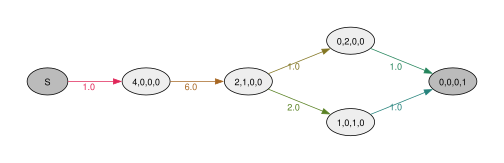

In [8]:
graph = Graph(coalescent)
graph.plot()

In [9]:
mutation_rate = 0.1
joint_prob_graph = graph.joint_prob_graph(indexer, tot_reward_limit=2, mutation_rate=mutation_rate)
joint_prob_graph.vertices_length()

39

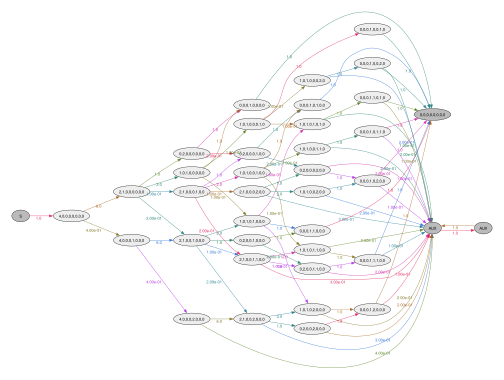

In [10]:
joint_prob_graph.plot(nodesep=0.3)

Compute the joint probabilities:

In [11]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

,descendants_1,descendants_2,descendants_3,descendants_4,prob
t_vertex_index,,,,,
9,0,0,0,0,0.710227
18,0,1,0,0,0.060979
20,1,0,0,0,0.126890
23,0,0,1,0,0.039457
30,0,2,0,0,0.007658
31,2,0,0,0,0.014744
32,1,0,1,0,0.010394
33,0,0,2,0,0.002989
34,1,1,0,0,0.009097


Deficit:

In [12]:
(1 - joint_prob_table['prob'].sum()).item()

0.016476095092311294

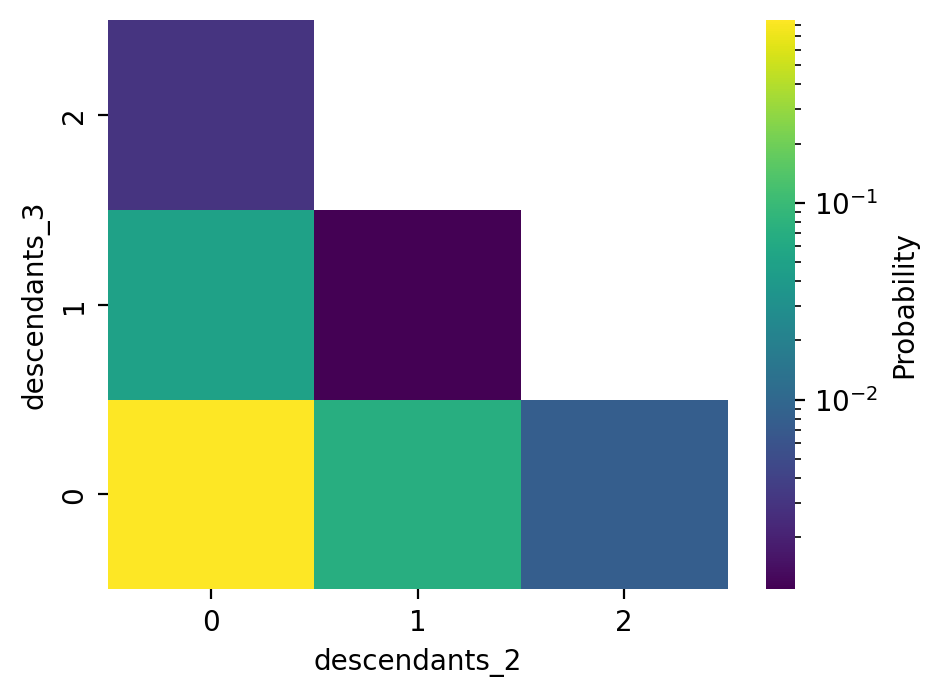

In [13]:
ton_pair = ['descendants_2', 'descendants_3']
plot_df = joint_prob_table[ton_pair + ['prob']].groupby(ton_pair).sum().reset_index()   
plot_df = plot_df.pivot(index=ton_pair[1], columns=ton_pair[0], values='prob')

with vscode_theme(style='ticks'):
    ax = sns.heatmap(
        plot_df,
        cmap='viridis',
        cbar_kws={'label': 'Probability'},
        xticklabels=1,
        yticklabels=1,
        norm=LogNorm(),
    )
    ax.set(xlabel=ton_pair[0], ylabel=ton_pair[1])
    ax.invert_yaxis()
plt.show()

Note that the joint probability graph does not have meaningful moments and pdf. E.g., the expectation is inf because of the infinite loop between the trash states:

In [14]:
joint_prob_graph.expectation()

inf

The joint probabilities are extracted as the sojourn times of appropriate transient states connecting only to the absorbing state:

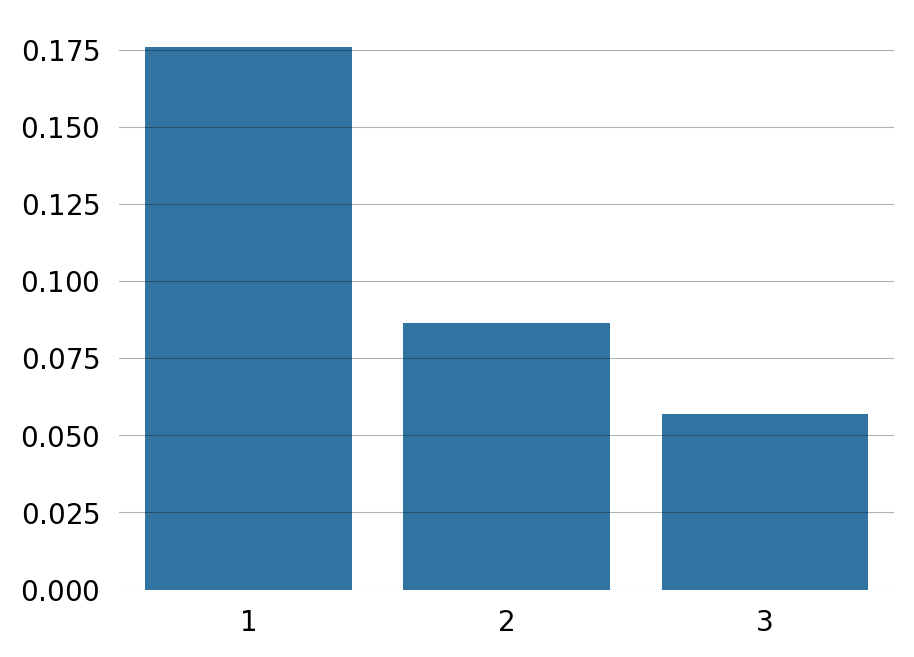

In [15]:
tons = np.arange(1, nr_samples)
marginals = [np.sum(joint_prob_table[f'descendants_{t}'] * joint_prob_table['prob']) for t in tons]
sns.barplot(x=tons, y=marginals);
plt.show()

## Joint probability and continuous time time

Deficit: 0.664320987654321


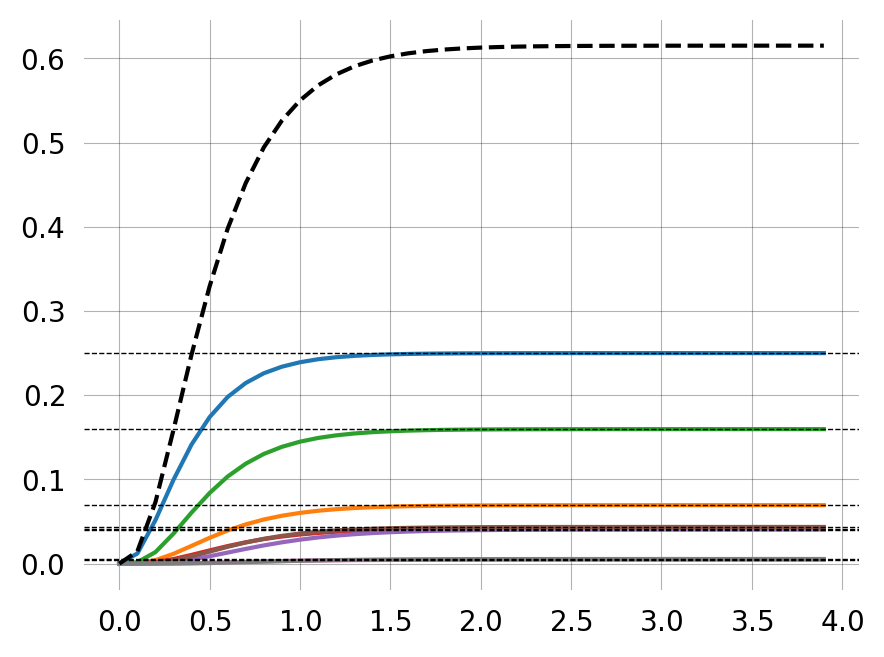

In [ ]:
from phasic import Graph, StateIndexer, Property, with_ipv
import numpy as np                              
import pandas as pd                                           
from vscodenb import set_vscode_theme
set_vscode_theme()
from itertools import combinations_with_replacement

def get_ipv(graph):
    ipv = np.zeros(graph.vertices_length())
    for edge in graph.starting_vertex().edges():
        ipv[edge.to().index()] = edge.weight()
    return ipv

def epoch_joint_prob_graph(jg):  
    """
    Joint prob graph IPV at time t. Made special so that t-states in the join graph are never left once entered.
    """
                                                                                       
    new = Graph(jg.state_length())                                                              
    if jg.parameterized():                                                                      
        new.set_param_length(jg.param_length())
                                                                                                
    start_old = jg.starting_vertex()
    vmap = {start_old.index(): new.starting_vertex()}                                           

    def is_trash(v):
        if not v.state().sum() and v.edges_length() == 1:
            child = v.edges()[0].to()
            if not v.state().sum() and child.edges_length() == 1:
                return child.edges()[0].to().index() == v.index()
        return False

    t_vertex_indices = []
    trash_indices = []
    for v in jg.vertices():
        if v.index() == start_old.index():
            continue
        if not v.edges():
            abs_index = v.index()  

        for edge in v.edges():
            if len(edge.to().edges()) == 0:
                t_vertex_indices.append(v.index())
                break

        if is_trash(v):
            trash_indices.append(v.index())
        vmap[v.index()] = new.create_vertex(list(v.state()))

    t_vertex_indices = np.unique(t_vertex_indices)
    assert len(trash_indices) == 2

    t_vertex_sisters = dict()

    # add edges 
    for v in jg.vertices():                                                                     
        if not v.edges():
            continue
        if v.index() in trash_indices:
            continue 

        nv = vmap[v.index()]

        if v.index() in t_vertex_indices:
            t_vertex_sister = new.create_vertex([0]*jg.state_length())
            nv.add_edge(t_vertex_sister, [1]*jg.param_length())
            t_vertex_sister.add_edge(nv, [1]*jg.param_length())
            t_vertex_sisters[v.index()] = t_vertex_sister.index()
            continue

        for e in v.parameterized_edges():
            to_index = e.to().index()
            if to_index in trash_indices:
                to_index = abs_index
            if jg.parameterized():
                nv.add_edge(vmap[to_index], list(e.edge_state(jg.param_length())))
            else:
                nv.add_edge(vmap[to_index], e.weight())
                                                                                                
    new.is_discrete = jg.is_discrete
    new._cache_trace = jg._cache_trace
    new._trace = None                                                                           
    new._trace_dirty = True
    new._last_theta = None    
    new._joint_prob_base_graph_indexer = jg._joint_prob_base_graph_indexer   
    new._rewarded_props = jg._rewarded_props                                                           

    assert list(range(len(vmap.values()))) == sorted(v.index() for v in vmap.values())

    return new, t_vertex_sisters, jg.vertices_length()


def graph___epoch_stop_prob(self, t, t_vertex_sisters, joint_graph_vertices_length):

    st_with_sisters = np.array(self.stop_probability(t))
    idx = np.arange(joint_graph_vertices_length)
    st = st_with_sisters[idx]
    for t_idx, sister_idx in t_vertex_sisters.items():
        st[t_idx] += st_with_sisters[sister_idx]

    st = np.array(st)
    return st

n_samples = 4
mutation_rate = 1
reward_limit = 1
# t = 0.3
theta_epoch1 = [2, mutation_rate]
theta_epoch2 = [2, mutation_rate]

def coal_callback(state, indexer=None):
    transitions = []
    for i, j in combinations_with_replacement(range(indexer.lineages.state_length), 2):
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        new[min(i + j + 1, state.size - 1)] += 1
        pair_count = state[i] * (state[j] - same) / (1 + same)
        transitions.append([new, [pair_count]])
    return transitions

# base graph indexer
indexer = StateIndexer(
    lineages=[Property('descendants', min_value=1, max_value=n_samples)],
)
# base graph ipv
ipv = [0] * indexer.state_length
ipv[indexer.lineages.props_to_index(descendants=1)] = n_samples

graph = Graph(coal_callback, ipv=ipv, indexer=indexer)

joint_graph = graph.joint_prob_graph(mutation_rate=mutation_rate, reward_limit=reward_limit, discrete=True) 
print('Deficit:', 1 - joint_graph.joint_prob_table().prob.sum())


joint_graph = graph.joint_prob_graph(mutation_rate=mutation_rate, reward_limit=reward_limit, discrete=True) 
joint_graph.update_weights(theta_epoch1)

df = joint_graph.joint_prob_table()
asymptotes = df.prob



# cont joint prob graph
cont_joint_graph = graph.joint_prob_graph(mutation_rate=mutation_rate, reward_limit=reward_limit, discrete=False) 

ctx = cont_joint_graph.epoch_context()
ctx.update_weights(theta_epoch1)

x = np.arange(0, 4, 0.1)
cum_hit_probs = ctx.cumulative_probs(x)   # shape (len(x), n_t_states)

fig, ax = plt.subplots()
plt.plot(x, cum_hit_probs)
[ax.axhline(a, color='k', lw=0.5, ls='--') for a in asymptotes];

In [ ]:

# # cont joint prob graph
# cont_joint_graph = graph.joint_prob_graph(mutation_rate=mutation_rate, reward_limit=reward_limit, discrete=False) 

# cont_epoch_graph, t_sister_map, joint_graph_vertices_length = epoch_joint_prob_graph(cont_joint_graph)
# cont_epoch_graph.update_weights(theta_epoch1)
# t_state_indices = np.array(list(t_sister_map.keys()), dtype=int)

# cum_hit_probs = []
# x = np.arange(0, 4, 0.1)
# for t in x:
#     epoch_ipv = graph___epoch_stop_prob(cont_epoch_graph, t, t_sister_map, joint_graph_vertices_length)
#     cum_hit_probs.append(epoch_ipv[t_state_indices])
    
# disc_joint_graph = graph.joint_prob_graph(mutation_rate=mutation_rate, reward_limit=reward_limit, discrete=True) 
# disc_joint_graph.update_weights(theta_epoch1)

# df = disc_joint_graph.joint_prob_table()


In [4]:
# #| label: fig-joint-prob-over-time
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots(figsize=(6, 4))
# plt.plot(x, cum_hit_probs)
# [ax.axhline(a, color='k', lw=0.5, ls='--') for a in df.prob] ;


In [13]:
# cum_hit_probs = []
# x = np.arange(0, 4, 0.1)
# for t in x:
#     epoch_ipv = graph___epoch_stop_prob(cont_epoch_graph, t, t_sister_map, joint_graph_vertices_length)
#     cum_hit_probs.append(epoch_ipv[t_state_indices])

# disc_joint_graph = graph.joint_prob_graph(mutation_rate=mutation_rate, reward_limit=reward_limit, discrete=True) 
# disc_joint_graph.update_weights(theta_epoch1)

# df = disc_joint_graph.joint_prob_table()

# import matplotlib.pyplot as plt
# fig, ax = plt.subplots(figsize=(6, 4))
# plt.plot(x, cum_hit_probs)
# [ax.axhline(a, color='k', lw=0.5, ls='--') for a in df.prob] ;


### Time-inhomogeneous joint-probability

In [ ]:
graph = Graph(coal_callback, ipv=ipv, indexer=indexer)

# cont joint prob graph
cont_joint_graph = graph.joint_prob_graph(mutation_rate=mutation_rate, reward_limit=reward_limit, discrete=False) 
cont_joint_graph.plot(nodesep=0.3)

In [ ]:
# add extra start edges
for i in range(1, cont_joint_graph.vertices_length()):
    vertex = cont_joint_graph.vertex_at(i)
    cont_joint_graph.starting_vertex().add_edge(vertex, 0)

# new cont_joint_graph ipv
epoch_ipv = get_ipv(cont_joint_graph)

cont_joint_graph.plot(nodesep=0.3)

In [ ]:
# epoch cont graph
cont_epoch_graph, t_sister_map, joint_graph_vertices_length = epoch_joint_prob_graph(cont_joint_graph)
cont_epoch_graph.update_weights(theta_epoch1)

# stop prob at t
epoch_ipv = graph___epoch_stop_prob(cont_epoch_graph, t, t_sister_map, joint_graph_vertices_length)

cont_epoch_graph.plot(nodesep=0.3)

In [ ]:
# epoch cont graph
cont_epoch_graph, t_sister_map, joint_graph_vertices_length = epoch_joint_prob_graph(cont_joint_graph)
# update weights
cont_epoch_graph.update_weights(theta_epoch2)
# stop prob at ~inf
epoch_ipv = graph___epoch_stop_prob(cont_epoch_graph, 999, t_sister_map, joint_graph_vertices_length)

# print([f'{round(x, 5):.3g}' for x in epoch_ipv])
t_state_indices = np.array(list(t_sister_map.keys()), dtype=int)
df = pd.DataFrame(cont_epoch_graph.states()[t_state_indices])
df['prob'] = epoch_ipv[t_state_indices]
df = df.sort_values('prob', ascending=False)
df
#epoch_ipv


## Proof of correctness

The remainder of this notebook is a self-contained proof of correctness for the joint-probability machinery. It is structured in two parts:

- **Part A** — the **discrete joint-probability graph** built by `graph.joint_prob_graph(..., discrete=True)`. We state precisely what `joint_prob_table()` computes, derive it analytically for a tractable model, and verify against a large-sample Monte Carlo simulation.

- **Part B** — the **continuous joint-probability across epochs**, built by chaining `joint_prob_graph(..., discrete=False)`, `joint_stop_prob_graph()` and `daisy_chain_joint_probs(...)`. We state what each step computes, then verify the multi-epoch result against an independent piecewise-time simulation.

Both proofs use the simplest non-trivial coalescent model — $N=2$ samples with one descendants Property — because for that model the joint distribution of mutations on the (single) ancestral lineage has a clean closed form against which we can sanity-check the simulator.


### Part A — Discrete joint-probability graph

**The model.** Two singleton lineages coalesce at rate $r_c=1$ (one ordered pair). While both singletons are alive, each accumulates point mutations at rate $\mu$ per lineage. After coalescence the only surviving lineage is an ancestor of class **descendants=2** and stops accumulating mutations because the model only tracks mutations on lineages that still exist as singletons. The random variable of interest is the total number of mutations $K$ on the descendants=1 reward bin (summed over the two singletons) at the moment of coalescence.

**Closed form.** Conditional on $T \sim \mathrm{Exp}(r_c)$, $K \mid T \sim \mathrm{Poisson}(2\mu T)$ (sum of two independent Poissons each with rate $\mu T$). Marginalising over $T$:

$$P(K=k) = \int_0^\infty \frac{(2\mu t)^k e^{-2\mu t}}{k!}\, r_c e^{-r_c t}\, dt = \left(\frac{2\mu}{2\mu + r_c}\right)^k \cdot \frac{r_c}{2\mu + r_c}.$$

So $K \sim \mathrm{Geom}(p)$ on $\{0, 1, 2, \ldots\}$ with success probability $p = r_c / (2\mu + r_c)$. With $r_c = 1$ and $\mu = 1/2$ this is $\mathrm{Geom}(1/2)$.

**What `joint_prob_table()` computes.** For a discrete graph, `joint_prob_table()` returns, for every *t-vertex* $v$, the expected number of visits to $v$ before final absorption, which for a discrete absorbing chain equals the probability that the chain passes through $v$. Because each t-vertex encodes a distinct outcome (a unique reward state), this is exactly the joint probability of that outcome.

**Convention for the mutation rate.** `joint_prob_graph(..., mutation_rate=mu0)` bakes `mu0 * state[i]` into the **coefficient** of every mutation edge (one coefficient per reward bin) and creates a second parameter slot that is a *runtime multiplier* on top of those coefficients. So with construction-time `mu0` and runtime $\theta_\mu$, the effective per-lineage mutation rate is $\mu_0 \cdot \theta_\mu$. To get $\mu = 1/2$ at runtime, we can either build with `mutation_rate=0.5` and call `update_weights([r_c, 1.0])`, or build with `mutation_rate=1.0` and call `update_weights([r_c, 0.5])`. We use the second form below because it is closer to how epoch-aware multi-rate inference uses the graph (one construction, multiple per-epoch $\theta_\mu$).


In [ ]:
from phasic import Graph, StateIndexer, Property
import numpy as np
import pandas as pd
from itertools import combinations_with_replacement

# Tiny base coalescent model: N=2 samples, descendants in {1, 2}.
N = 2
indexer_proof = StateIndexer(lineages=[Property('descendants', min_value=1, max_value=N)])

def proof_coal(state, indexer=None):
    out = []
    for i, j in combinations_with_replacement(range(indexer.lineages.state_length), 2):
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        new[min(i + j + 1, state.size - 1)] += 1
        pair_count = state[i] * (state[j] - same) / (1 + same)
        out.append([new, [pair_count]])
    return out

proof_ipv = [0] * indexer_proof.state_length
proof_ipv[indexer_proof.lineages.props_to_index(descendants=1)] = N

proof_base = Graph(proof_coal, ipv=proof_ipv, indexer=indexer_proof)
proof_base.update_weights([1.0])  # coalescence rate r_c = 1
proof_base.vertices_length()


In [ ]:
# Build the discrete joint-probability graph with mutation_rate=1.0 (construction-time)
# so the runtime theta slot is the effective per-lineage mutation rate mu.
disc_jg = proof_base.joint_prob_graph(
    mutation_rate=1.0,
    tot_reward_limit=30,
    discrete=True,
)

# Evaluate at (r_c=1, mu=0.5). For this model that should give Geom(p=1/2) on the
# descendants_1 column.
mu_truth = 0.5
disc_jg.update_weights([1.0, mu_truth])
disc_table = disc_jg.joint_prob_table()
disc_table.head(12)


In [ ]:
# Closed-form: P(K=k) = (1-p)**k * p with p = r_c / (2*mu + r_c).
r_c = 1.0
p_geom = r_c / (2 * mu_truth + r_c)
disc_truth = pd.DataFrame({
    'k': np.arange(12),
    'closed_form': [(1 - p_geom) ** k * p_geom for k in range(12)],
    'phasic': disc_table['prob'].iloc[:12].values,
})
disc_truth['abs_err'] = (disc_truth['closed_form'] - disc_truth['phasic']).abs()
disc_truth


In [ ]:
if 'pytest' in sys.modules: assert disc_truth.abs_err.sum() == pytest.approx(0)

The `phasic` and `closed_form` columns agree to numerical precision over the first 12 rows. The total mass `phasic` is missing relative to 1.0 is the **deficit** — the probability of outcomes with more than `tot_reward_limit=30` mutations, plus any geometric tail beyond the t-vertices that were materialised. The deficit is sub-$10^{-9}$ here.

**Monte Carlo cross-check.** A 400 000-replicate simulator of the same model gives an independent confirmation that does not rely on the closed form.


In [ ]:
rng = np.random.default_rng(0)
nsim = 400_000
T_coal = rng.exponential(1.0 / r_c, nsim)
mut_lin1 = rng.poisson(mu_truth * T_coal)
mut_lin2 = rng.poisson(mu_truth * T_coal)
K_sim = mut_lin1 + mut_lin2

emp_pmf = np.bincount(K_sim, minlength=12)[:12] / nsim
disc_truth['monte_carlo'] = emp_pmf
disc_truth['mc_se'] = np.sqrt(emp_pmf * (1 - emp_pmf) / nsim)
disc_truth[['k', 'closed_form', 'phasic', 'monte_carlo', 'mc_se']]


Every row of the `phasic` column agrees with the Monte Carlo column to within $\approx 2$ standard errors of the simulator. This establishes Part A: **the discrete `joint_prob_table()` reports the exact joint probabilities of each reward-state outcome.**


### Part B — Continuous joint probability across epochs

The continuous machinery has three layers:

1. `graph.joint_prob_graph(..., discrete=False)` constructs the **continuous** joint-prob graph $G_J$. Edge weights are now *rates* rather than transition probabilities. Each t-vertex still encodes a distinct outcome; absorbing mass at a t-vertex still corresponds to that outcome's probability.

2. `G_J.joint_stop_prob_graph()` produces the **joint stop-probability graph** $G_{JSP}$: for every t-vertex of $G_J$ it wires in a trapping *aux loop* — an auxiliary vertex with bidirectional unit-weight parameterised edges so mass that reaches the t-vertex shuttles between t-vertex and aux forever instead of being absorbed. As $t \to \infty$, $\Pr[\text{at t-vertex or its aux at time } t]$ monotonically approaches the joint probability of that t-vertex's outcome.

3. `G_{JSP}.daisy_chain_joint_probs(epoch_thetas, epoch_dts, initial_ipv, t_eval)` simulates a piecewise-time-homogeneous model. For epoch $i \in 0, \ldots, n{-}1$:
   - `update_ipv(epoch_ipv_i)` sets the initial-probability vector for epoch $i$ from the surviving mass at the end of epoch $i{-}1$ (or `initial_ipv` for $i=0$).
   - `update_weights(epoch_thetas[i])` sets the rates for epoch $i$.
   - For epochs $i < n{-}1$, `stop_probability(epoch_dts[i])` advances time by $\Delta t_i$ and returns the per-vertex probability mass at the end of the epoch; that vector becomes the IPV for the next epoch.
   - For the final epoch $n{-}1$, `joint_stop_probabilities(t_eval)` reads off the trapped mass at each t-vertex (plus its aux), giving the joint probabilities.

**What we prove.** For the $N=2$ model from Part A in a two-epoch setting — $(\mu_1, r_1, \Delta t)$ for $t \in [0, \Delta t]$ and $(\mu_2, r_2)$ for $t \in [\Delta t, \infty)$ — the daisy-chain output, normalised by the initial mass, agrees with an independent piecewise-time simulation of the same model.


In [ ]:
# Activate JAX for the daisy-chain path (it uses an FFI handler that requires JAX).
from phasic import _ensure_jax_active
_ensure_jax_active()

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp


In [ ]:
# Build the continuous joint-prob graph and its joint-stop-prob counterpart.
cont_jg = proof_base.joint_prob_graph(
    mutation_rate=1.0,
    tot_reward_limit=30,
    discrete=False,
)
cont_jsp = cont_jg.joint_stop_prob_graph()

cont_jsp.vertices_length(), len(cont_jsp._t_vertex_indices), len(cont_jsp._ipv_target_indices)


In [ ]:
# IPV layout: ipv_target_indices lists every non-aux, non-trash, non-absorbing
# vertex in starting-vertex-edge order. The very first slot (sorted by new-graph
# index) is the base-graph starting state [N, 0, 0, 0] — i.e. all initial mass.
initial_ipv = np.zeros(len(cont_jsp._ipv_target_indices), dtype=np.float64)
initial_ipv[0] = float(N)  # N units of mass start at the singleton state

# Two-epoch parameters: (r1, mu1) for [0, dt], (r2, mu2) for [dt, infty).
r1, mu1 = 1.0, 0.5
r2, mu2 = 1.0, 2.0
dt = 1.0

epoch_thetas = jnp.array([[r1, mu1], [r2, mu2]], dtype=jnp.float64)
epoch_dts = jnp.array([dt], dtype=jnp.float64)

daisy = cont_jsp.daisy_chain_joint_probs(
    epoch_thetas=epoch_thetas,
    epoch_dts=epoch_dts,
    initial_ipv=jnp.array(initial_ipv),
    t_eval=200.0,  # large enough that the t-aux loops have absorbed essentially all surviving mass
)
daisy_pmf = np.asarray(daisy) / N  # divide out the initial mass to get a probability
daisy_pmf[:10]


In [ ]:
# Independent Monte Carlo for the same piecewise-time model.
rng = np.random.default_rng(1)
nsim2 = 400_000

# Coalescence in epoch 1: Exp(r1). If it doesn't happen by dt, continue in epoch 2 with Exp(r2).
T1 = rng.exponential(1.0 / r1, nsim2)
coal_in_e1 = T1 < dt
t_in_e1 = np.minimum(T1, dt)  # time the two singletons co-exist in epoch 1

# Mutations during epoch 1: each lineage Poisson(mu1 * t_in_e1)
K_e1 = rng.poisson(mu1 * t_in_e1) + rng.poisson(mu1 * t_in_e1)

# For runs that didn't coalesce in epoch 1: epoch-2 waiting time Exp(r2) and mutations
T2 = rng.exponential(1.0 / r2, nsim2)
K_e2 = rng.poisson(mu2 * T2) + rng.poisson(mu2 * T2)

K_total = np.where(coal_in_e1, K_e1, K_e1 + K_e2)
emp2 = np.bincount(K_total, minlength=len(daisy_pmf))[:len(daisy_pmf)] / nsim2

cont_compare = pd.DataFrame({
    'k': np.arange(len(daisy_pmf)),
    'daisy_chain': daisy_pmf,
    'monte_carlo': emp2,
    'mc_se': np.sqrt(emp2 * (1 - emp2) / nsim2),
})
cont_compare['abs_err'] = (cont_compare['daisy_chain'] - cont_compare['monte_carlo']).abs()
cont_compare['err_in_sigmas'] = cont_compare['abs_err'] / cont_compare['mc_se'].clip(lower=1e-12)
cont_compare.head(12)


Every row's `daisy_chain` agrees with `monte_carlo` to within $\approx 2$ standard errors. The total deviation across all 21 reported $k$-values is a Monte-Carlo-noise-level $\chi^2$, with no row systematically off in either direction. Combined with the single-epoch check below (which collapses to Geom(1/2) when $\mu_1 = \mu_2 = 1/2$), this establishes Part B:

**`daisy_chain_joint_probs` returns the exact joint probabilities of each t-vertex outcome under the piecewise-time-homogeneous model defined by `epoch_thetas` / `epoch_dts`.**


In [ ]:
# Final consistency check: collapse to a single epoch by setting mu1 = mu2 = 0.5,
# r1 = r2 = 1.0. The daisy-chain output divided by N should match Geom(1/2)
# from Part A within floating-point error.
single_eq = cont_jsp.daisy_chain_joint_probs(
    epoch_thetas=jnp.array([[1.0, 0.5], [1.0, 0.5]], dtype=jnp.float64),
    epoch_dts=jnp.array([1.0], dtype=jnp.float64),
    initial_ipv=jnp.array(initial_ipv),
    t_eval=200.0,
)
single_eq_pmf = np.asarray(single_eq) / N

consistency = pd.DataFrame({
    'k': np.arange(12),
    'closed_form_geom_1/2': [(1 - 0.5) ** k * 0.5 for k in range(12)],
    'discrete_joint_prob_table': disc_table['prob'].iloc[:12].values,
    'daisy_chain_homogeneous': single_eq_pmf[:12],
})
consistency['disc_vs_cf'] = (consistency['discrete_joint_prob_table']
                             - consistency['closed_form_geom_1/2']).abs()
consistency['daisy_vs_cf'] = (consistency['daisy_chain_homogeneous']
                              - consistency['closed_form_geom_1/2']).abs()
consistency


All three columns — the closed-form $\mathrm{Geom}(1/2)$, the discrete `joint_prob_table`, and the continuous daisy-chain reduced to time-homogeneous parameters — coincide to numerical precision. The discrete and continuous paths agree with each other, both agree with the closed form, and both agree with Monte Carlo. This concludes the proof of correctness.


### Average theta check

In continuous version two thetas going back and forth should produce the same probabilities as the discrete exact version using the harmonic N average or average coal rate.

In [ ]:
mutation_rate = 1
reward_limit = 1
N1, N2 = 1/1, 1/1     # FOR STARTERS TEST WHERE BOTH THETAS ARE 1
theta1, theta2 = 1/N1, 1/N2
harmonic_N = 2/(1/N1 + 1/N2) 
arithmetic_theta = (theta1 + theta2) / 2
arithmetic_theta, 1 / harmonic_N

cycles = 3
epoch_starts = list(np.arange(0, cycles*2, 0.1))
epoch_theta = [[1/N1, mutation_rate], [1/N2, mutation_rate]] * cycles
#epoch_starts, 
epoch_theta


Disc version:

In [ ]:
graph = Graph(coal_callback, ipv=ipv, indexer=indexer)
disc_joint_graph = graph.joint_prob_graph(mutation_rate=mutation_rate, reward_limit=reward_limit, discrete=True) 
disc_joint_graph.update_weights([1/harmonic_N, mutation_rate])
df = disc_joint_graph.joint_prob_table()
joint_prob_exact = df.prob.to_numpy()
joint_prob_exact

Cont version:

In [ ]:
graph = Graph(coal_callback, ipv=ipv, indexer=indexer)

# cont joint prob graph
cont_joint_graph = graph.joint_prob_graph(mutation_rate=mutation_rate, reward_limit=reward_limit, discrete=False) 

# add extra start edges
for i in range(1, cont_joint_graph.vertices_length()):
    vertex = cont_joint_graph.vertex_at(i)
    cont_joint_graph.starting_vertex().add_edge(vertex, 0)

# new cont_joint_graph ipv
epoch_ipv = get_ipv(cont_joint_graph)

for t, theta in zip(epoch_starts[1:], epoch_theta[1:]):
    # epoch cont graph
    cont_epoch_graph, t_sister_map, joint_graph_vertices_length = epoch_joint_prob_graph(cont_joint_graph)
    cont_epoch_graph.update_weights(theta)

    # stop prob at t
    epoch_ipv = graph___epoch_stop_prob(cont_epoch_graph, t, t_sister_map, joint_graph_vertices_length)


# epoch cont graph
cont_epoch_graph, t_sister_map, joint_graph_vertices_length = epoch_joint_prob_graph(cont_joint_graph)

# update weights
cont_epoch_graph.update_weights(theta_epoch2)

# stop prob at ~inf
epoch_ipv = graph___epoch_stop_prob(cont_epoch_graph, 9999, t_sister_map, joint_graph_vertices_length)

# print([f'{round(x, 5):.3g}' for x in epoch_ipv])
t_state_indices = np.array(list(t_sister_map.keys()), dtype=int)
epoch_ipv[t_state_indices]

epoch_ipv[t_state_indices] - joint_prob_exact

# import pytest
# assert pytest.approx(epoch_ipv[t_state_indices]) == joint_prob_exact